In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import kagglehub

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

dataset_dir = kagglehub.dataset_download("brandao/diabetes")
df = pd.read_csv(f"{dataset_dir}/diabetic_data.csv")

print("Shape:", df.shape)

df["readmitted"] = df["readmitted"].map({
    "NO": 0,
    "<30": 1,
    ">30": 2
})

y = df["readmitted"]


drop_cols = ["encounter_id", "patient_nbr"]
X = df.drop(columns=drop_cols + ["readmitted"])


X = X.replace("?", np.nan)

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = X[col].fillna(X[col].mode()[0])
    else:
        X[col] = X[col].fillna(X[col].median())


for col in X.select_dtypes(include="object").columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

print("Preprocessing done ✔")


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)
y_test = torch.tensor(y_test.values, dtype=torch.long)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 3)
        )

    def forward(self, x):
        return self.model(x)

model = MLP(X_train.shape[1])


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

epochs = 20

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")


model.eval()
with torch.no_grad():
    outputs = model(X_test)
    y_pred = torch.argmax(outputs, axis=1).numpy()

print("\nClassification Report:\n")
print(classification_report(y_test.numpy(), y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test.numpy(), y_pred))

100%|██████████| 4.41M/4.41M [00:00<00:00, 50.2MB/s]

Extracting files...


Shape: (101766, 50)
Preprocessing done ✔
Epoch 1/20, Loss: 0.9650
Epoch 2/20, Loss: 0.9190
Epoch 3/20, Loss: 0.9032
Epoch 4/20, Loss: 0.8950
Epoch 5/20, Loss: 0.8898
Epoch 6/20, Loss: 0.8860
Epoch 7/20, Loss: 0.8827
Epoch 8/20, Loss: 0.8798
Epoch 9/20, Loss: 0.8790
Epoch 10/20, Loss: 0.8770
Epoch 11/20, Loss: 0.8744
Epoch 12/20, Loss: 0.8730
Epoch 13/20, Loss: 0.8708
Epoch 14/20, Loss: 0.8696
Epoch 15/20, Loss: 0.8686
Epoch 16/20, Loss: 0.8663
Epoch 17/20, Loss: 0.8670
Epoch 18/20, Loss: 0.8650
Epoch 19/20, Loss: 0.8637
Epoch 20/20, Loss: 0.8628

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.79      0.69     10973
           1       0.20      0.12      0.15      2272
           2       0.48      0.33      0.39      7109

    accuracy                           0.55     20354
   macro avg       0.43      0.41      0.41     20354
weighted avg       0.52      0.55      0.52     20354


Confusion Matrix:

[[8635  564 1774]
 [12

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

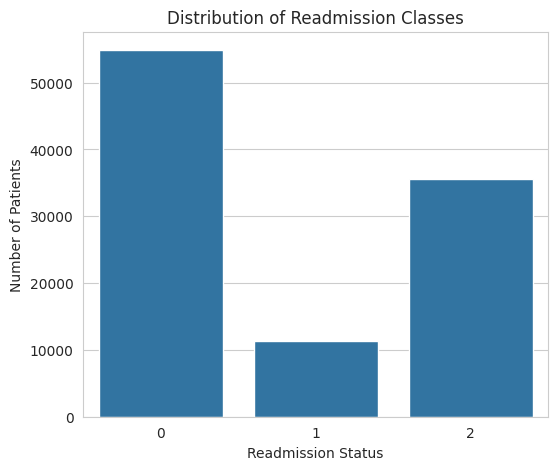

In [4]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="readmitted")
plt.title("Distribution of Readmission Classes")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")
plt.show()

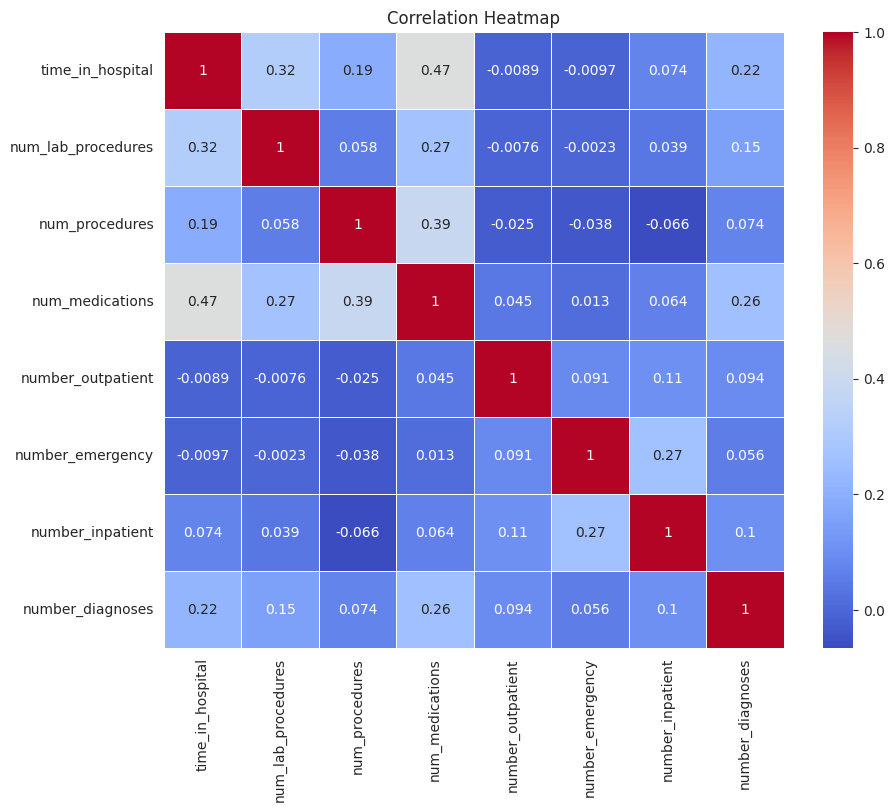

In [5]:
numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

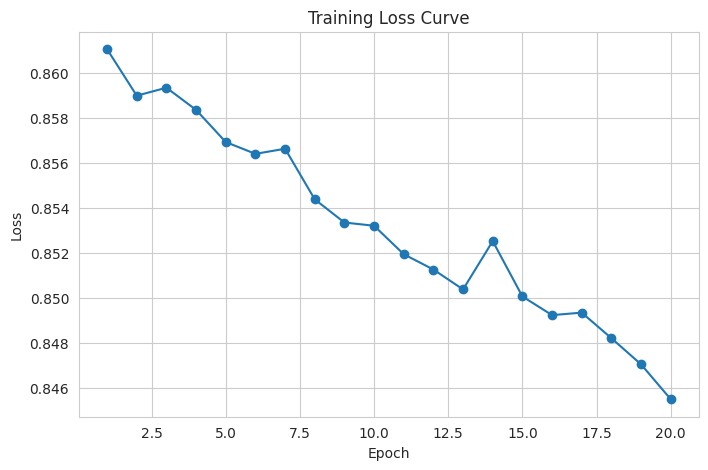

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), train_losses, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

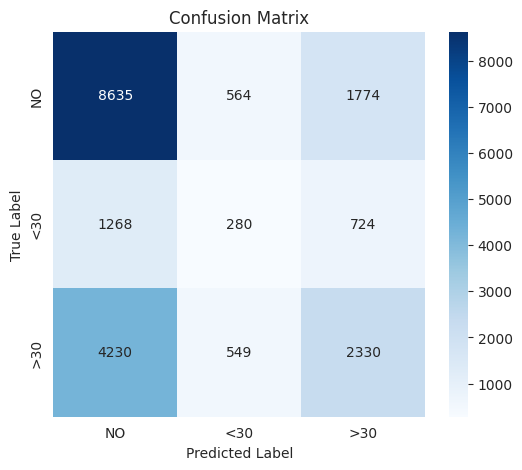

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test.numpy(), y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NO","<30",">30"],
    yticklabels=["NO","<30",">30"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()